# Day 3: Data Analysis - Home Notebook
## Objectives

In this session, you will use Python to:
- Load and inspect a dataset with pandas.
- Summarize numeric and categorical variables.
- Make exploratory plots.
- Compare two variables and interpret the result.
- Save a figure and write a short conclusion.

This notebook follows the same style as the previous home notebooks: read the question, run the code, and familiarize with coding. Take this notebook to test different parameters and try to solve problems on your own.

---
## 1) Which packages do you need for data analysis?

Import the libraries you will need for this homework.

In [1]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.formula.api as smf

---
## 2) How do you load the dataset and inspect its structure?

Use the cleaned penguin dataset from Day 2 (`penguins_clean.csv`). Your goal is to check that the file loads correctly and to inspect the table structure before making any plots or summaries.


In [4]:
df = pd.read_csv("penguins_clean.csv")
print(df)

for col in ["row_id", "species", "island", "sex", "observation_year"]:
    df[col] = df[col].astype("category")

df.info()

     row_id    species     island  bill_length_mm  bill_depth_mm  \
0         1     Adelie  Torgersen            39.1           18.7   
1         2     Adelie  Torgersen            39.5           17.4   
2         3     Adelie  Torgersen            40.3           18.0   
3         5     Adelie  Torgersen            36.7           19.3   
4         6     Adelie  Torgersen            39.3           20.6   
..      ...        ...        ...             ...            ...   
328     340  Chinstrap      Dream            55.8           19.8   
329     341  Chinstrap      Dream            43.5           18.1   
330     342  Chinstrap      Dream            49.6           18.2   
331     343  Chinstrap      Dream            50.8           19.0   
332     344  Chinstrap      Dream            50.2           18.7   

     flipper_length_mm  body_mass_g     sex  observation_year  
0                181.0       3750.0    male              2007  
1                186.0       3800.0  female            

---
## 3) Which numeric variable would you explore first?

Choose one numeric variable from the dataset and print its summary statistics. Pay attention to the mean, median, standard deviation, and range. This helps you understand the distribution before plotting it.


In [5]:
#figuring out what columns are numerical where all floats or int are numerical
print(df.dtypes)
# I choose to continue with the numerical variable body_mass_g:

row_id               category
species              category
island               category
bill_length_mm        float64
bill_depth_mm         float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
observation_year     category
dtype: object


In [14]:
#Making summary statistics for body mass:
print(df["body_mass_g"].describe().round(2))

column_name = "body_mass_g"

print("Mean:", df[column_name].mean()) #Is the mean value
print("Median:", df[column_name].median()) #The median
print("Std Dev:", df[column_name].std()) # Standard deviation
print("Range:", df[column_name].max() - df[column_name].min()) #How much the weight ranges

count    333.00
mean    4207.06
std      805.22
min     2700.00
25%     3550.00
50%     4050.00
75%     4775.00
max     6300.00
Name: body_mass_g, dtype: float64
Mean: 4207.057057057057
Median: 4050.0
Std Dev: 805.2158019428964
Range: 3600.0


---
## 4) Set up the right data type and pick which categorical variable would you explore next?

The dataset contains both numeric and categorical information. Before plotting, make sure that the categorical columns are stored as text-like values. Then choose one categorical variable and count how often each category appears.


In [20]:
#Making the catecorical columns as text-like values
for col in ["row_id", "species", "island", "sex", "observation_year"]:
    df[col] = df[col].astype("category")

print(df.dtypes)

#I want to count for species
df["species"].value_counts()

row_id               category
species              category
island               category
bill_length_mm        float64
bill_depth_mm         float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
observation_year     category
dtype: object


species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

---
## 5) How can you inspect the distribution of a numeric variable?

Make a histogram and a boxplot for the numeric variable you chose. Use this to identify skewness, spread, and possible outliers.


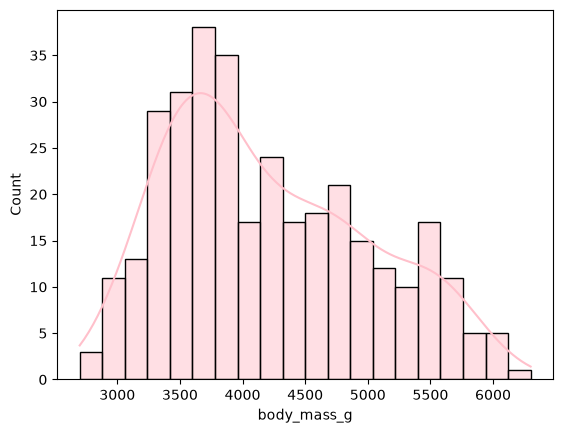

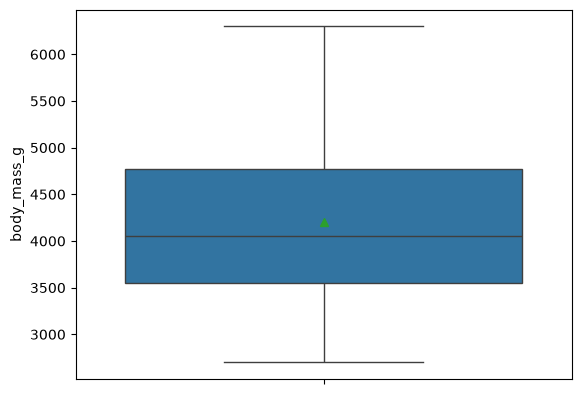

In [26]:
#Making a histogram
sns.histplot(x = df["body_mass_g"], 
             bins = 20, 
             kde = True, 
             color = "pink")
plt.show()

#Making a boxplot
sns.boxplot(y = df["body_mass_g"], showmeans = True)
plt.show()

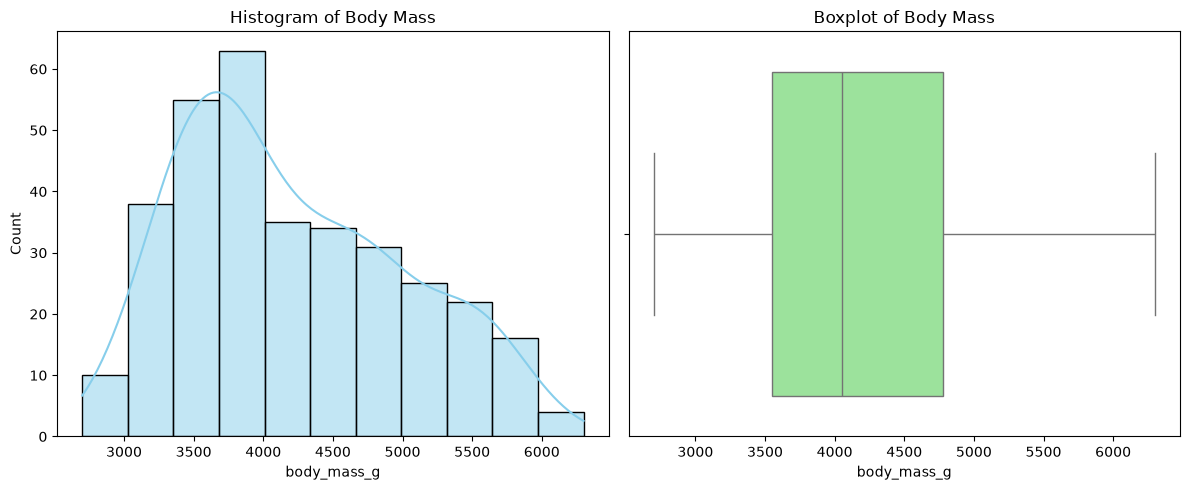

In [29]:
# Set up a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Histogram with KDE line
sns.histplot(
    data=df, x="body_mass_g", kde=True, ax=axes[0], color="skyblue"
)
axes[0].set_title("Histogram of Body Mass")

# 2. Boxplot
sns.boxplot(data=df, x="body_mass_g", ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot of Body Mass")

plt.tight_layout()
plt.show()

---
## 6) How can you inspect the distribution of a categorical variable?

Create a count plot for the category you selected. This helps you understand whether the groups are balanced or whether one category dominates the dataset.


/var/folders/c1/rhyvjp9548jbv6gbklns3hbc0000gn/T/ipykernel_29545/1851582099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="species", palette="Set2")


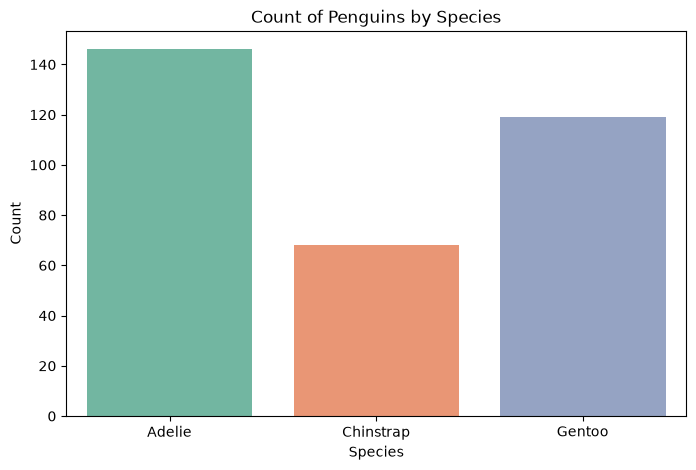

In [30]:
# Create a count plot for a categorical column (e.g., 'species')
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="species", palette="Set2")

# Add title and labels
plt.title("Count of Penguins by Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

---
## 7) How do you compare two quantitative variables?

Choose two numeric variables and make a scatter plot with a regression line. This helps you inspect whether the variables move together, and whether a simple linear trend is present.


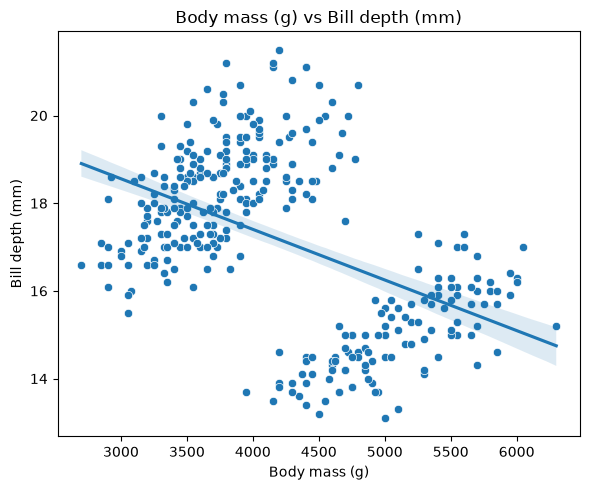

In [34]:
# Set column names for analysis. Replace the defaults if you want to explore different variables.
quantitative_x = "body_mass_g"
quantitative_y = "bill_depth_mm"
group_column = "species"
outcome_column = "body_mass_g" #should be numerical
group_a = "Adelie"
group_b = "Chinstrap"

#Richer plotting:
fig, ax =plt.subplots(figsize = (6,5)) #fig, ax = adressing two objects at the same time
sns.scatterplot(data = df, x = quantitative_x, y = quantitative_y, ax = ax) #gonna add more thing, a regression line
sns.regplot(data = df, x = quantitative_x, y = quantitative_y, scatter = False, ax = ax)
ax.set_title("Body mass (g) vs Bill depth (mm)") #setting more of the details of the plot
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Bill depth (mm)")
plt.tight_layout() #layout improvements
plt.show()


---
## 8) How do you compare one numeric variable across two groups?

Select one grouping variable and one numeric outcome. Then use a boxplot to compare the distribution of the outcome across the two groups.


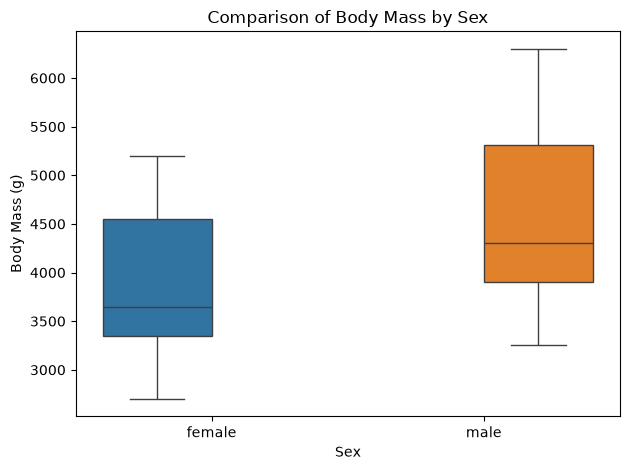

In [44]:
#Making a boxplot
sns.boxplot(data=df, x="sex", y="body_mass_g", hue = "sex")

# Customizing titles and labels
plt.title("Comparison of Body Mass by Sex")
plt.xlabel("Sex")
plt.ylabel("Body Mass (g)")
plt.tight_layout()
plt.show()

---
## 9) How do you save one figure and wrap up the analysis?

Save one figure to disk and use a short written interpretation to explain what the plot shows. This is the same logic you will use in reports and assignments.


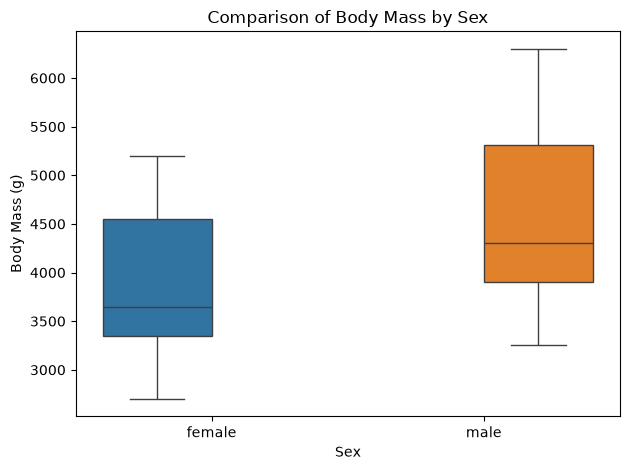

In [41]:
sns.boxplot(data=df, x="sex", y="body_mass_g", hue = "sex")

# Customizing titles and labels
plt.title("Comparison of Body Mass by Sex")
plt.xlabel("Sex")
plt.ylabel("Body Mass (g)")
plt.tight_layout()

plt.savefig("Sex_bodymass_boxplot.png", dpi = 300)

#Interpretation
#It seems like on average females are smaller in body mass than their male counterparts.

---
## 10) Compare two groups with a simple statistical question

Use the same dataset and answer the following question in one or two sentences:

- Does the distribution of `body_mass_g` look different between `male` and `female` in  `Gentoo` penguins?
- Which plot would you use to answer this question, and why?
- Test if there is a statistically significant differance.


In [49]:
#Making a boxplot to look at the difference between male and female body mass in Gentoo

# Code to inspect the values first
gentoo_df = df[df["species"] == "Gentoo"]
print(gentoo_df.groupby("sex")["body_mass_g"].describe().round(2))

        count    mean    std     min     25%     50%     75%     max
sex                                                                 
female  58.00 4679.74 281.58 3950.00 4462.50 4700.00 4875.00 5200.00
male    61.00 5484.84 313.16 4750.00 5300.00 5500.00 5700.00 6300.00


/var/folders/c1/rhyvjp9548jbv6gbklns3hbc0000gn/T/ipykernel_29545/731430767.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gentoo, x="sex", y="body_mass_g", palette="Set2")


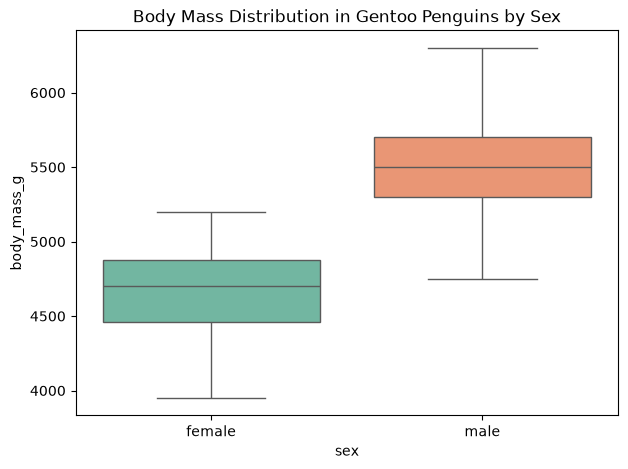

p-value: 2.1337e-28


In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Filter for Gentoo penguins and drop missing values in sex or body mass
gentoo = df[(df["species"] == "Gentoo")].dropna(subset=["sex", "body_mass_g"])

# Plot: Boxplot comparing body mass across sex
plt.figure(figsize=(7, 5))
sns.boxplot(data=gentoo, x="sex", y="body_mass_g", palette="Set2")
plt.title("Body Mass Distribution in Gentoo Penguins by Sex")
plt.show()

# Test: Two-sample t-test between male and female Gentoo penguins
males = gentoo[gentoo["sex"] == "male"]["body_mass_g"]
females = gentoo[gentoo["sex"] == "female"]["body_mass_g"]

t_stat, p_val = stats.ttest_ind(males, females)
print(f"p-value: {p_val:.4e}")

---
## 11) Extra practice: Wrong Data Category
Set `observation_year` to float and plot a PCA. Compare with the figure seen in class and write a note on how mislabeled data types can bias your analysis.

In [52]:
#Summary of our statistics
display(df[numeric_cols].head()) 

# Reminder : PCA cannot handle missing values
pca_df = df[numeric_cols].dropna() #PCA cannot handle NAs

#Scaling everything to the same standards, every value is how sentered it is according to their dispersion
#putting everything to the same units
X = StandardScaler().fit_transform(pca_df)

print(X)

#Now to run the PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("PCA features names:", pca_df.columns.tolist())

plot_df = pd.DataFrame(pcs, columns = ["PC1", "PC2"], index=pca_df.index)
for meta in ("species", "sex"): #separatiing species and sex
    if meta in df.columns:
        plot_df[meta] = df.loc[plot_df.index, meta].values


hue = "species"
style = "sex"
sns.scatterplot(data=plot_df, x = "PC1", y = "PC2", hue = hue, style = style) 

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.10,18.70,181.00,3750.00
1,39.50,17.40,186.00,3800.00
2,40.30,18.00,195.00,3250.00
3,36.70,19.30,193.00,3450.00
4,39.30,20.60,190.00,3650.00


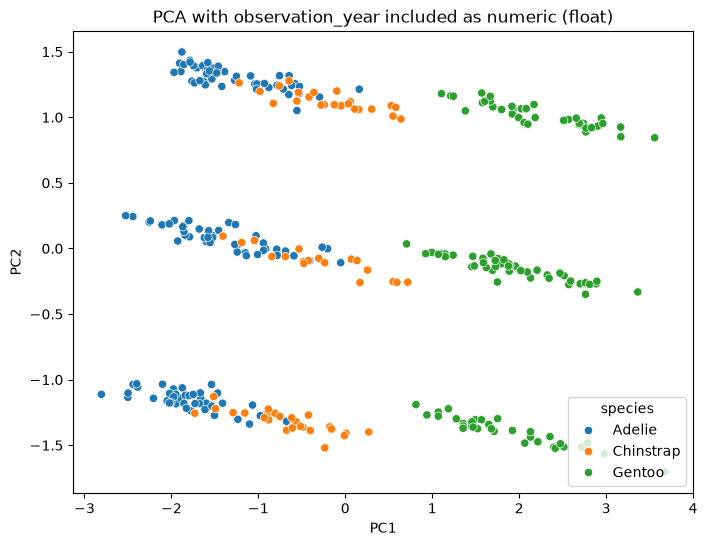

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cast observation_year to float so it gets included as a numeric feature
df["observation_year"] = df["observation_year"].astype(float)

# 2. Select numeric columns (now including observation_year) and drop NAs
numeric_cols = df.select_dtypes(include=["number"]).columns
pca_df = df[numeric_cols].dropna()

# 3. Standardize features and run PCA
X = StandardScaler().fit_transform(pca_df)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

# 4. Prepare data for plotting
plot_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=pca_df.index)
if "species" in df.columns:
    plot_df["species"] = df.loc[plot_df.index, "species"]

# 5. Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="species")
plt.title("PCA with observation_year included as numeric (float)")
plt.show()

---
## 12) Extra practice: modelling
Make a linear model that estimate `body_mass_g` using other other numerical variables and `species` and summarize your fitted model.
